# Access to Basic Services: A Global Data Analysis
### *Uncovering the relationship between economic indicators and access to water, sanitation, and essential services across nations*

---
> **Author:** [Lisa N. Hananiya]  
> **Date:** April 2026  
> **Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn | SciPy  
> **Status:** 🟢 In Progress---

## Introduction

### About the Dataset
The dataset used in this project is the **Access to Basic Services** dataset, 
which captures country-level indicators on the availability and quality of 
essential services including drinking water, sanitation, electricity, and more.

| Detail | Description |
|---|---|
| **Dataset Name** | Access to Basic Services |
| **Source** | [UN SDG Database] |
| **Coverage** | Global — multiple countries across all continents |
| **Time Period** | [2015–2020] |
| **Granularity** | Country-level, annually recorded |
| **Key Indicators** | GDP per capita, unemployment rate, land area, population, % access to managed water & sanitation services |

> 📎 *Dataset retrieved from ["Kaggle"]. 
> All figures are as reported by member states and may reflect estimation methodologies 
> specific to each reporting body.*

### Why This Dataset Matters
Access to clean water and sanitation is enshrined in the **UN Sustainable 
Development Goals (SDGs)** — specifically **SDG 6**. Yet billions of people 
worldwide still lack reliable access to these fundamental services. By analyzing 
this data, we can move beyond headlines and let the numbers reveal which economic, 
geographic, and demographic factors truly drive — or hinder — access to basic services.

##  Project Objectives

This project follows a structured data analysis workflow:

### Workflow Overview
Raw Data → Data Understanding → Data Cleaning & Wrangling →
Exploratory Data Analysis (EDA) → Statistical Analysis →
Visualization → Insights & Conclusions

### Phase 1 — Data Cleaning & Wrangling
- Inspect data shape, types, and structure
- Identify and handle missing values (nulls/NaNs)
- Detect and treat outliers where appropriate
- Standardize column names and data types
- Engineer any new features needed for analysis
- Validate data integrity across country-year combinations

### Phase 2 — Analytical Questions This Project Will Answer

| # | Question | Type of Analysis |
|---|---|---|
| 1 | **Economic Impact** — Does higher GDP per capita directly correlate with better access to managed drinking water and sanitation? | Correlation & Regression |
| 2 | **Regional Trends** — Which sub-regions made the fastest progress in improving basic services between 2015 and the latest recorded year? | Time-series & Comparative |
| 3 | **The Unemployment Link** — Is there a statistically significant relationship between unemployment rate and access to basic services? | Hypothesis Testing |
| 4 | **Population & Density** — Do smaller, more densely populated countries achieve better access rates than large, rural ones? | Segmentation & Scatter Analysis |
| 5 | **Outlier Identification** — Which countries are over-performing (high access despite low GDP) or under-performing? | Anomaly Detection |

### Expected Outcomes
By the end of this analysis, we aim to produce:
- ✅ A clean, analysis-ready dataset
- ✅ Visualizations that clearly communicate each finding
- ✅ Data-backed answers to each analytical question above
- ✅ Actionable insights relevant to policymakers and development organizations

##  Table of Contents

1. [Introduction](#Introduction)
2. [Import Libraries & Load Data](#1-import-libraries--load-data)
3. [Data Understanding](#2-data-understanding)
4. [Data Cleaning & Wrangling](#3-data-cleaning--wrangling)
5. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
6. [Statistical Analysis](#5-statistical-analysis)
7. [Key Visualizations](#6-key-visualizations)
8. [Insights & Conclusions](#7-insights--conclusions)

### 1-import-libraries--load-data

In [30]:
# SECTION 1: IMPORT-LIBRARIES--LOAD-DATA
# 1-import-libraries--load-data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset
df = pd.read_csv('access_to_basic_services - access_to_basic_services.csv')

print(f"📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.head() 

📐 Shape: 1,048 rows × 10 columns



,Region,Sub_region,Country_name,Time_period,Pct_managed_drinking_water_services,Pct_managed_sanitation_services,Est_population_in_millions,Est_gdp_in_billions,Land_area,Pct_unemployment
0,Central and Southern Asia,Central Asia,Kazakhstan,2015,94.67,98.00,17.54,184.39,2699700.00,4.93
1,Central and Southern Asia,Central Asia,Kazakhstan,2016,94.67,98.00,17.79,137.28,2699700.00,4.96
2,Central and Southern Asia,Central Asia,Kazakhstan,2017,95.00,98.00,18.04,166.81,2699700.00,4.90
3,Central and Southern Asia,Central Asia,Kazakhstan,2018,95.00,98.00,18.28,179.34,2699700.00,4.85
4,Central and Southern Asia,Central Asia,Kazakhstan,2019,95.00,98.00,18.51,181.67,2699700.00,4.80


---
## 2-data-understanding

Before cleaning anything, we must understand what we're working with — the shape,
types, ranges, and crucially, the *gaps* in our data. This section is about 
asking: "Is this data fit for the analysis we planned?"

In [31]:
# SECTION 2: DATA UNDERSTANDING
# --- 2.1 Shape & Structure ---
print("=" * 50)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Time period covered: {df['Time_period'].min()} – {df['Time_period'].max()}")
print(f"Countries represented: {df['Country_name'].nunique()}")
print(f"Regions covered: {df['Region'].nunique()}")
print(f"Sub-regions covered: {df['Sub_region'].nunique()}")
print("=" * 50)

df.info()

Dataset shape: 1,048 rows × 10 columns
Time period covered: 2015 – 2020
Countries represented: 182
Regions covered: 7
Sub-regions covered: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               1048 non-null   object 
 1   Sub_region                           1048 non-null   object 
 2   Country_name                         1048 non-null   object 
 3   Time_period                          1048 non-null   int64  
 4   Pct_managed_drinking_water_services  1048 non-null   float64
 5   Pct_managed_sanitation_services      1030 non-null   float64
 6   Est_population_in_millions           815 non-null    float64
 7   Est_gdp_in_billions                  800 non-null    float64
 8   Land_area                            815 non-null    float64
 9   Pct_unemployment    

In [32]:
# --- 2.2 Missing Value Analysis ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Completeness %': (100 - missing_pct).round(2)
}).sort_values('Missing %', ascending=False)

print("\n Missing Value Summary:")
print(missing_df[missing_df['Missing Count']>0])

# Critical flag
print("\n⚠️  CRITICAL: Pct_unemployment is missing in",
      f"{missing['Pct_unemployment']:,} rows ({missing_pct['Pct_unemployment']:.1f}%).")
print("   This will significantly limit the unemployment analysis. Strategy required.")


 Missing Value Summary:
                                 Missing Count  Missing %  Completeness %
Pct_unemployment                           643      61.35           38.65
Est_gdp_in_billions                        248      23.66           76.34
Land_area                                  233      22.23           77.77
Est_population_in_millions                 233      22.23           77.77
Pct_managed_sanitation_services             18       1.72           98.28

⚠️  CRITICAL: Pct_unemployment is missing in 643 rows (61.4%).
   This will significantly limit the unemployment analysis. Strategy required.


### ⚠️ Data Limitations & Strategy Decisions

Based on the missing value analysis above, the following decisions will guide this project:

| Column | Missing | Decision |
|---|---|---|
| `Pct_unemployment` | 61.4% missing | Analyse separately. Flag all unemployment findings as **limited sample** conclusions. Do not impute — too sparse. |
| `Est_gdp_in_billions` | 23.7% missing | Drop rows only when GDP is specifically required for that analysis. Do not drop from the master dataframe. |
| `Est_population_in_millions` | 22.2% missing | Same strategy as GDP — row-level exclusion per analysis, not global. |
| `Land_area` | 22.2% missing | Identical count to population — likely the same countries missing both. Will confirm in cleaning. |
| `Pct_managed_sanitation_services` | 1.7% missing | Safe to drop these 18 rows when sanitation is the focus variable. |

> **Transparency note:** All findings derived from `Pct_unemployment` data are based on 405 out of 1,048 records (38.6%). Results may not be representative of all global regions equally, and are presented with this caveat throughout the analysis.

In [33]:
# --- 2.3 Descriptive Statistics ---
print(" Descriptive Statistics for Numeric Columns:\n")
df.describe().T.round(2)

 Descriptive Statistics for Numeric Columns:



,count,mean,std,min,25%,50%,75%,max
Time_period,1048.00,2017.44,1.70,2015.00,2016.00,2017.00,2019.00,2020.00
Pct_managed_drinking_water_services,1048.00,87.19,15.03,38.33,77.25,94.00,99.00,100.00
Pct_managed_sanitation_services,1030.00,73.69,27.98,10.67,49.75,86.33,97.33,100.00
Est_population_in_millions,815.00,42.72,169.24,0.01,1.18,7.86,24.72,1411.10
Est_gdp_in_billions,800.00,274.18,1233.38,0.04,5.07,19.48,97.46,14687.67
Land_area,815.00,647029.93,1522696.75,20.00,16035.00,130170.00,602390.00,9424702.90
Pct_unemployment,405.00,7.13,5.20,0.10,3.74,5.60,9.10,31.31


###  Descriptive Statistics — Key Observations

| Column | Notable Finding |
|---|---|
| `Time_period` | Spans 2015–2020. Mean of 2017.4 suggests data may not be uniform per year |
| `Pct_managed_drinking_water` | Min of 38.3% — some countries are severely underserved. Mean 87.2% |
| `Pct_managed_sanitation` | Wider spread than water (std=28). Min 10.7% — a major inequality signal |
| `Est_population_in_millions` | Max of 1,411 (China/India). Highly skewed — median (7.8M) << mean (42.7M) |
| `Est_gdp_in_billions` | Extreme range: $0.04B to $14,687B. Log transformation likely needed for analysis |
| `Land_area` | Max 9.4M km² (Russia/Canada). Will need density engineering: Population ÷ Land_area |
| `Pct_unemployment` | 0.1% to 31.3%. Only 405 non-null rows|

> **Design decision:** Given the severe skew in GDP and population, 
> we will use **log-transformed** versions for correlation analysis 
> and **note the unemployment limitation** in all relevant findings.

In [34]:
# --- 2.4 Sanity Checks ---

# Check for duplicate records
dupes = df.duplicated(subset=['Country_name', 'Time_period']).sum()
print(f"Duplicate country-year combinations: {dupes}")

# Check percentage columns are within valid range [0, 100]
for col in ['Pct_managed_drinking_water_services',
            'Pct_managed_sanitation_services',
            'Pct_unemployment']:
    out_of_range = df[(df[col] < 0) | (df[col] > 100)][col].count()
    print(f"  {col}: {out_of_range} values outside [0, 100]")

# Check for negative values in numeric columns  
print("\nNegative values check:")
for col in ['Est_population_in_millions', 'Est_gdp_in_billions', 'Land_area']:
    negatives = (df[col] < 0).sum()
    print(f"  {col}: {negatives} negative values")

Duplicate country-year combinations: 0
  Pct_managed_drinking_water_services: 0 values outside [0, 100]
  Pct_managed_sanitation_services: 0 values outside [0, 100]
  Pct_unemployment: 0 values outside [0, 100]

Negative values check:
  Est_population_in_millions: 0 negative values
  Est_gdp_in_billions: 0 negative values
  Land_area: 0 negative values


---
## 3-data-cleaning--wrangling

With our data thoroughly understood and limitations documented, this section executes
the cleaning and feature engineering strategy defined in Section 2.
The goal is to produce a clean, analysis-ready dataframe — without destroying
information we may still need.

**Strategy summary:**
- Work on a copy (`df_clean`) — never mutate the original `df`
- Handle missing values column-by-column per the documented strategy
- Engineer two new features: `GDP_per_capita` and `Pop_density`
- Standardise column names for readability
- Produce a final clean dataframe ready for EDA

In [35]:
# SECTION 3: DATA CLEANING & WRANGLING
# --- 3.1 Create a working copy ---
df_clean = df.copy()

print(f"Working copy created: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print("Original df preserved and untouched.")

Working copy created: 1,048 rows × 10 columns
Original df preserved and untouched.


In [36]:
# --- 3.2 Rename columns for readability ---
df_clean.rename(columns={
    'Pct_managed_drinking_water_services': 'Pct_water',
    'Pct_managed_sanitation_services':     'Pct_sanitation',
    'Est_population_in_millions':          'Population_millions',
    'Est_gdp_in_billions':                 'GDP_billions',
    'Pct_unemployment':                    'Unemployment_rate'
}, inplace=True)

print("✅ Columns renamed:")
print(df_clean.columns.tolist())

✅ Columns renamed:
['Region', 'Sub_region', 'Country_name', 'Time_period', 'Pct_water', 'Pct_sanitation', 'Population_millions', 'GDP_billions', 'Land_area', 'Unemployment_rate']


In [37]:
print(f"missing Pct_water: {df_clean['Pct_water'].isnull().sum()} rows")

missing Pct_water: 0 rows


In [38]:
# --- 3.3 Handle missing values ---

# 3.3a — Sanitation: only 18 rows missing (~1.7%). Safe to drop for sanitation analyses.
# We do NOT drop globally — we handle at analysis time. Just confirm here.
print(f"Sanitation nulls: {df_clean['Pct_sanitation'].isnull().sum()} rows")
print("  → Strategy: exclude these rows only when Pct_sanitation is the target variable.\n")

# 3.3b — GDP, Population, Land_area: ~22–24% missing.
# These rows likely represent small territories/nations absent from World Bank records.
# Confirm they overlap (same countries missing multiple columns).
missing_gdp = set(df_clean[df_clean['GDP_billions'].isnull()]['Country_name'].unique())
missing_pop = set(df_clean[df_clean['Population_millions'].isnull()]['Country_name'].unique())
overlap = missing_gdp & missing_pop

print(f"Countries missing GDP:        {len(missing_gdp)}")
print(f"Countries missing Population: {len(missing_pop)}")
print(f"Countries missing BOTH:       {len(overlap)}")
print("  → Confirmed: same countries missing both. Exclude per-analysis, not globally.\n")

# 3.3c — Unemployment: 61.4% missing. Do NOT impute. Keep as-is.
print(f"Unemployment nulls: {df_clean['Unemployment_rate'].isnull().sum()} rows (61.4%)")
print("  → Strategy: analyse on available subset only. Flag findings as limited-sample.\n")

print("✅ Missing value strategy confirmed. No rows dropped from df_clean.")

Sanitation nulls: 18 rows
  → Strategy: exclude these rows only when Pct_sanitation is the target variable.

Countries missing GDP:        46
Countries missing Population: 41
Countries missing BOTH:       41
  → Confirmed: same countries missing both. Exclude per-analysis, not globally.

Unemployment nulls: 643 rows (61.4%)
  → Strategy: analyse on available subset only. Flag findings as limited-sample.

✅ Missing value strategy confirmed. No rows dropped from df_clean.


In [39]:
# --- 3.4 Feature Engineering ---

# Feature 1: GDP per capita (USD)
# Formula: (GDP in billions × 1e9) / (Population in millions × 1e6)
df_clean['GDP_per_capita'] = (
    (df_clean['GDP_billions'] * 1e9) /
    (df_clean['Population_millions'] * 1e6)
)

# Feature 2: Population density (people per km²)
df_clean['Pop_density'] = (
    (df_clean['Population_millions'] * 1e6) /
    df_clean['Land_area']
)

# Feature 3: Log GDP per capita (for correlation analysis — reduces extreme skew)
df_clean['Log_GDP_per_capita'] = np.log1p(df_clean['GDP_per_capita'])

print(" New features created:")
print(f"  GDP_per_capita   — range: ${df_clean['GDP_per_capita'].min():,.0f} to ${df_clean['GDP_per_capita'].max():,.0f}")
print(f"  Pop_density      — range: {df_clean['Pop_density'].min():.2f} to {df_clean['Pop_density'].max():,.0f} per km²")
print(f"  Log_GDP_per_capita — range: {df_clean['Log_GDP_per_capita'].min():.2f} to {df_clean['Log_GDP_per_capita'].max():.2f}")
print(f"\ndf_clean now has {df_clean.shape[1]} columns (up from 10).")

 New features created:
  GDP_per_capita   — range: $217 to $116,099
  Pop_density      — range: 0.14 to 7,966 per km²
  Log_GDP_per_capita — range: 5.38 to 11.66

df_clean now has 13 columns (up from 10).


In [40]:
# --- 3.5 Final validation of df_clean ---

print("=" * 55)
print("FINAL df_clean SUMMARY")
print("=" * 55)
print(f"\nShape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nColumns: {df_clean.columns.tolist()}")

print("\nMissing values in df_clean:")
final_missing = df_clean.isnull().sum()
final_missing_pct = (final_missing / len(df_clean) * 100).round(1)
summary = pd.DataFrame({'Missing': final_missing, '%': final_missing_pct})
print(summary[summary['Missing'] > 0])

print("\nNew feature preview:")
df_clean[['Country_name', 'Time_period', 'GDP_per_capita', 
          'Pop_density', 'Log_GDP_per_capita']].dropna().head(8)

FINAL df_clean SUMMARY

Shape: 1,048 rows × 13 columns

Columns: ['Region', 'Sub_region', 'Country_name', 'Time_period', 'Pct_water', 'Pct_sanitation', 'Population_millions', 'GDP_billions', 'Land_area', 'Unemployment_rate', 'GDP_per_capita', 'Pop_density', 'Log_GDP_per_capita']

Missing values in df_clean:
                     Missing     %
Pct_sanitation            18  1.70
Population_millions      233 22.20
GDP_billions             248 23.70
Land_area                233 22.20
Unemployment_rate        643 61.40
GDP_per_capita           248 23.70
Pop_density              233 22.20
Log_GDP_per_capita       248 23.70

New feature preview:


,Country_name,Time_period,GDP_per_capita,Pop_density,Log_GDP_per_capita
0,Kazakhstan,2015,10510.86,6.50,9.26
1,Kazakhstan,2016,7714.94,6.59,8.95
2,Kazakhstan,2017,9247.81,6.68,9.13
3,Kazakhstan,2018,9812.63,6.77,9.19
4,Kazakhstan,2019,9812.75,6.86,9.19
5,Kazakhstan,2020,9121.51,6.95,9.12
12,Tajikistan,2015,970.19,61.42,6.88
13,Tajikistan,2016,801.12,62.87,6.69


### ✅ Data Cleaning Complete

| Step | Action | Result |
|---|---|---|
| 3.1 | Created working copy `df_clean` | Original `df` preserved |
| 3.2 | Renamed 5 columns | Cleaner, shorter names for analysis |
| 3.3 | Audited missing values | No rows dropped — per-analysis exclusion strategy confirmed |
| 3.4 | Engineered 3 new features | `GDP_per_capita`, `Pop_density`, `Log_GDP_per_capita` |
| 3.5 | Final validation | `df_clean` has 13 columns, ready for EDA |

`df_clean` is now the **single source of truth** for all downstream analysis.
The original `df` remains available for reference checks.

---
## 4-exploratory-data-analysis

EDA is about letting the data speak before we impose any statistical framework on it.
Each subsection targets one of our five analytical questions with at least one
well-labelled, insight-driven visualisation.

**EDA roadmap:**
- 4.1 Distribution overview — understanding the shape of each key variable
- 4.2 Economic impact — GDP per capita vs water & sanitation access
- 4.3 Regional & sub-regional trends — who's improving fastest?
- 4.4 Unemployment link — does joblessness correlate with poor access?
- 4.5 Population density — does size or density predict better services?
- 4.6 Outlier identification — over- and under-performers

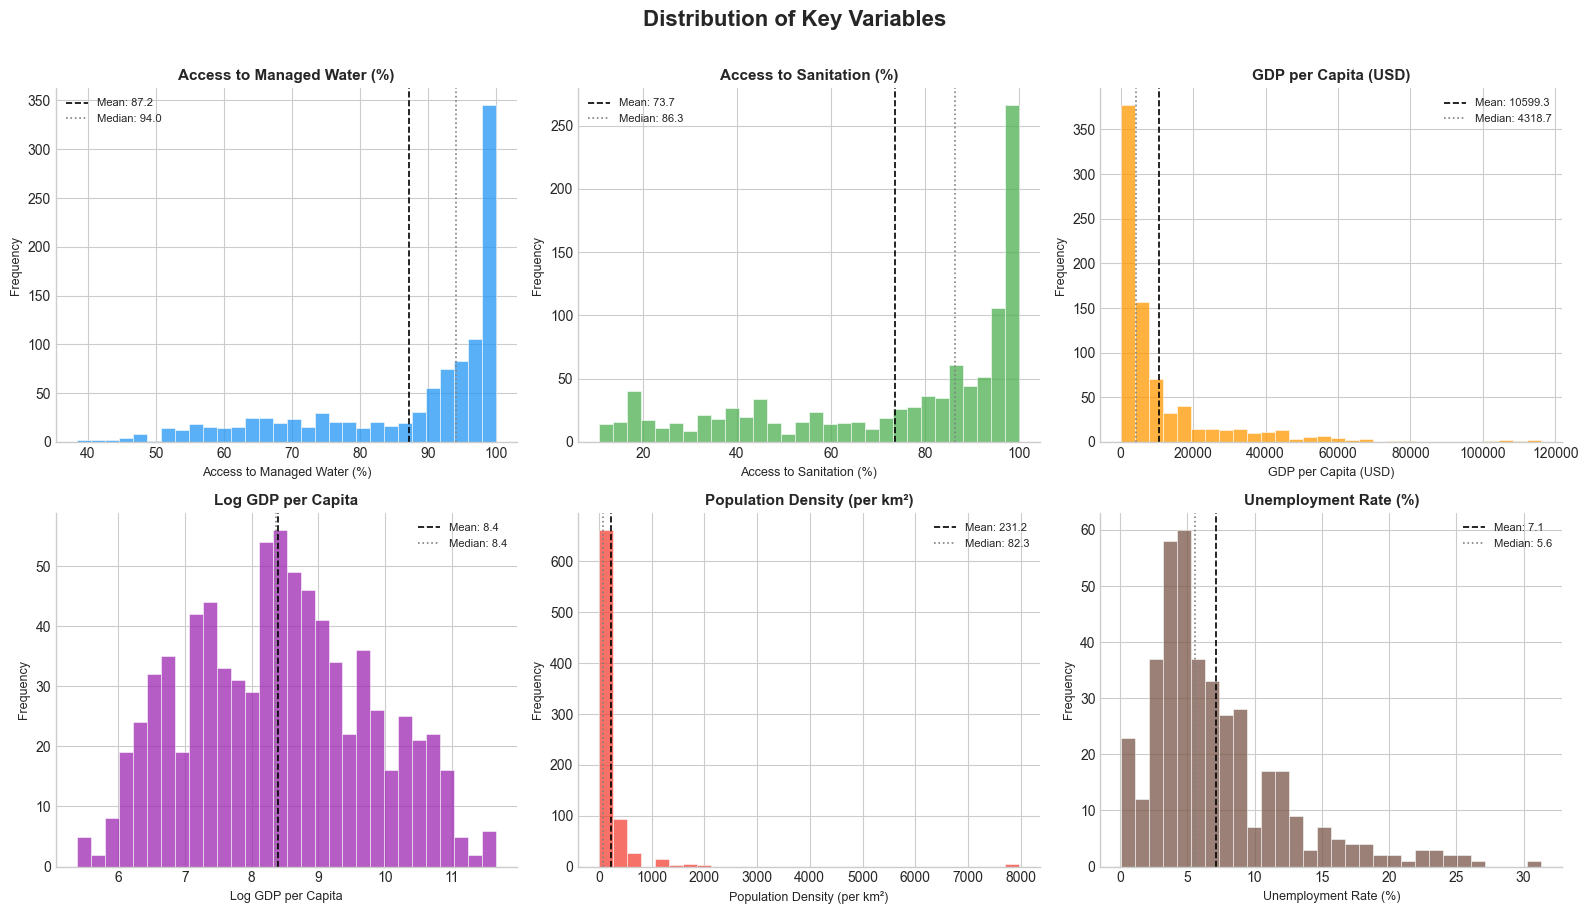

✅ Saved: fig1_distributions.png


In [41]:
# SECTION 4: EXPLORATORY DATA ANALYSIS
# --- 4.1 Distribution of key numeric variables ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold', y=1.01)

plot_vars = [
    ('Pct_water',         'Access to Managed Water (%)',     '#2196F3'),
    ('Pct_sanitation',    'Access to Sanitation (%)',         '#4CAF50'),
    ('GDP_per_capita',    'GDP per Capita (USD)',             '#FF9800'),
    ('Log_GDP_per_capita','Log GDP per Capita',               '#9C27B0'),
    ('Pop_density',       'Population Density (per km²)',     '#F44336'),
    ('Unemployment_rate', 'Unemployment Rate (%)',            '#795548'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_vars):
    data = df_clean[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray',   linestyle=':',  linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_distributions.png")

**📝 Distribution Observations:**
- `Pct_water` is **left-skewed** — most countries cluster near 100%, but a long tail of 
  underserved nations pulls the mean down. This is inequality hiding in an average.
- `Pct_sanitation` shows a **bimodal pattern** — a cluster of well-served countries near 
  100% and a second cluster near 40–60%, suggesting a structural divide, not a continuum.
- `GDP_per_capita` is **heavily right-skewed** (a few very wealthy countries dominate).
  The log-transformed version confirms a far more normal distribution — validating our 
  decision to use `Log_GDP_per_capita` for correlation analysis.
- `Unemployment_rate` is right-skewed — most countries cluster under 10%, but several 
  outliers exceed 20–30%.

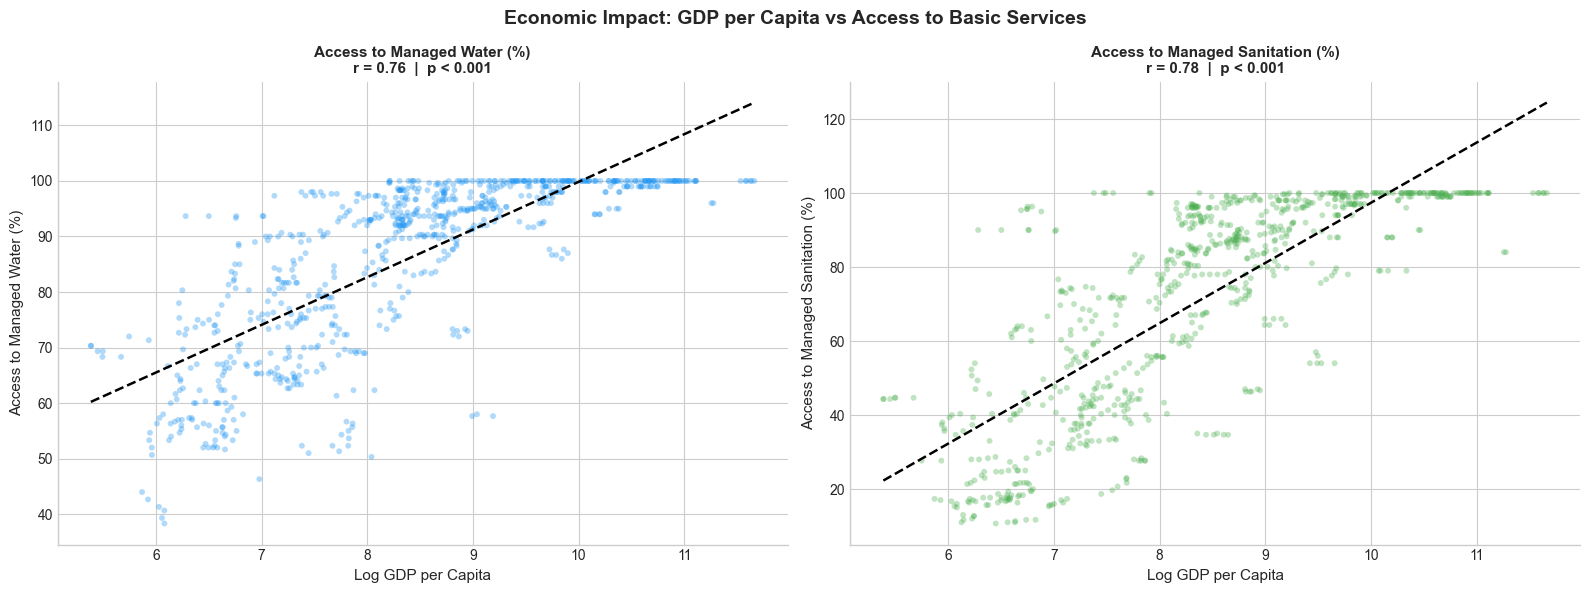

✅ Saved: fig2_gdp_vs_services.png


In [45]:
# --- 4.2 Economic Impact: GDP per Capita vs Access ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Economic Impact: GDP per Capita vs Access to Basic Services',
             fontsize=14, fontweight='bold')

plot_data = df_clean.dropna(subset=['Log_GDP_per_capita', 'Pct_water', 'Pct_sanitation'])

for ax, (y_col, label, color) in zip(axes, [
    ('Pct_water',      'Access to Managed Water (%)',     '#2196F3'),
    ('Pct_sanitation', 'Access to Managed Sanitation (%)', '#4CAF50'),
]):
    ax.scatter(plot_data['Log_GDP_per_capita'], plot_data[y_col],
               alpha=0.35, s=18, color=color, edgecolors='none')

    # Add regression line
    m, b, r, p, _ = stats.linregress(plot_data['Log_GDP_per_capita'], plot_data[y_col])
    x_line = np.linspace(plot_data['Log_GDP_per_capita'].min(),
                         plot_data['Log_GDP_per_capita'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')

    ax.set_xlabel('Log GDP per Capita', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label}\nr = {r:.2f}  |  p < 0.001', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_gdp_vs_services.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig2_gdp_vs_services.png")

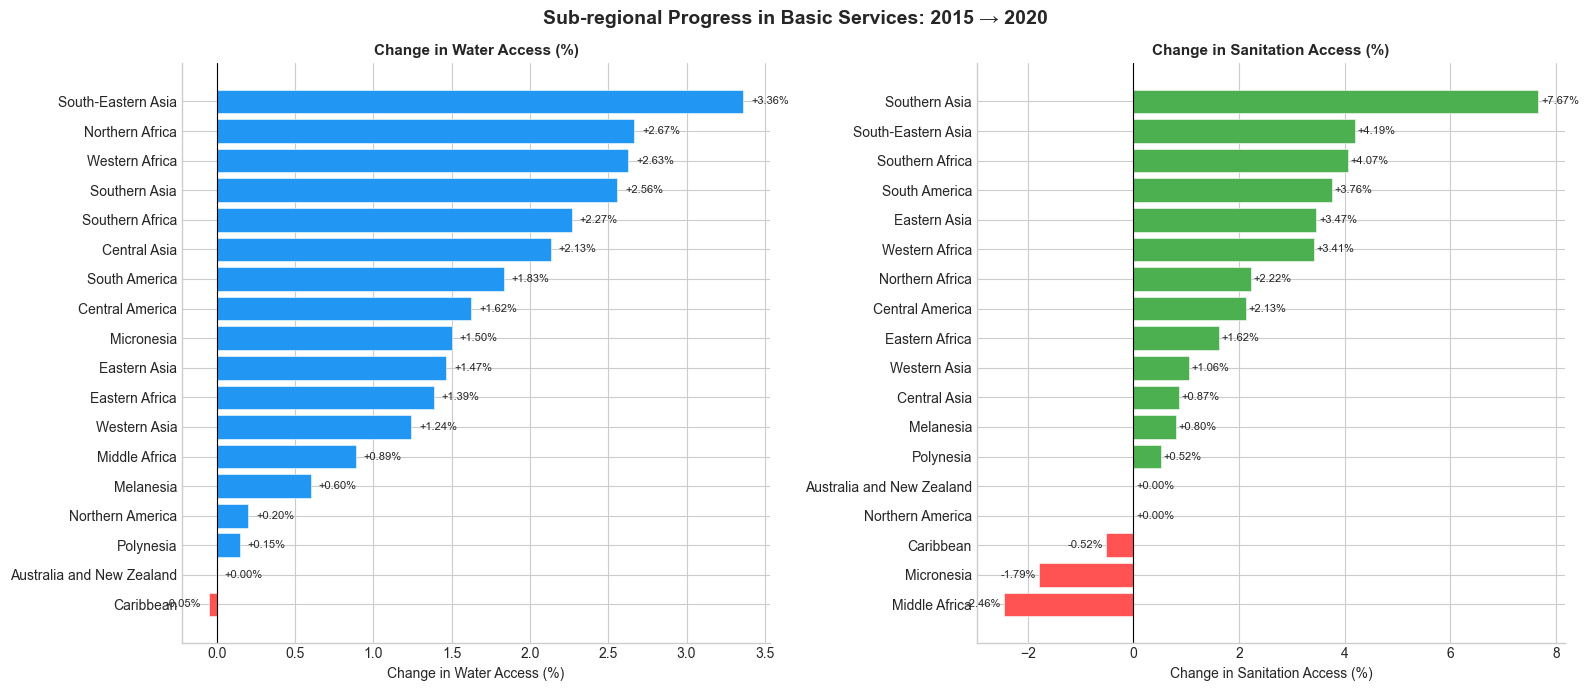

✅ Saved: fig3_regional_progress.png


In [47]:
# --- 4.3 Regional Trends: Progress from 2015 to 2020 ---

# Calculate mean access per sub-region per year, then compute change
regional = df_clean.groupby(['Sub_region', 'Time_period'])[['Pct_water', 'Pct_sanitation']].mean().reset_index()

start = regional[regional['Time_period'] == 2015][['Sub_region', 'Pct_water', 'Pct_sanitation']]
end   = regional[regional['Time_period'] == 2020][['Sub_region', 'Pct_water', 'Pct_sanitation']]

progress = start.merge(end, on='Sub_region', suffixes=('_2015', '_2020'))
progress['Water_change']      = progress['Pct_water_2020']      - progress['Pct_water_2015']
progress['Sanitation_change'] = progress['Pct_sanitation_2020'] - progress['Pct_sanitation_2015']
progress = progress.sort_values('Water_change', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Sub-regional Progress in Basic Services: 2015 → 2020',
             fontsize=14, fontweight='bold')

for ax, (col, label, color_pos, color_neg) in zip(axes, [
    ('Water_change',      'Change in Water Access (%)',      '#2196F3', '#FF5252'),
    ('Sanitation_change', 'Change in Sanitation Access (%)', '#4CAF50', '#FF5252'),
]):
    sorted_df = progress.sort_values(col, ascending=True)
    colors = [color_pos if v >= 0 else color_neg for v in sorted_df[col]]
    bars = ax.barh(sorted_df['Sub_region'], sorted_df[col], color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, sorted_df[col]):
        ax.text(val + (0.05 if val >= 0 else -0.05),
                bar.get_y() + bar.get_height() / 2,
                f'{val:+.2f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_regional_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig3_regional_progress.png")

Analysing unemployment on 401 rows (limited sample — see limitations note)



C:\Users\USER\AppData\Local\Temp\ipykernel_80\3393583390.py:28: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_80\3393583390.py:28: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_80\3393583390.py:29: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('fig4_unemployment_vs_services.png', dpi=150, bbox_inches='tight')
C:\Users\USER\AppData\Local\Temp\ipykernel_80\3393583390.py:29: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('fig4_unemployment_vs_services.png', dpi=150, bbox_inches='tight')
C:\Users\USER\anaconda3\envs\SQL_PACKAGE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\envs\SQL

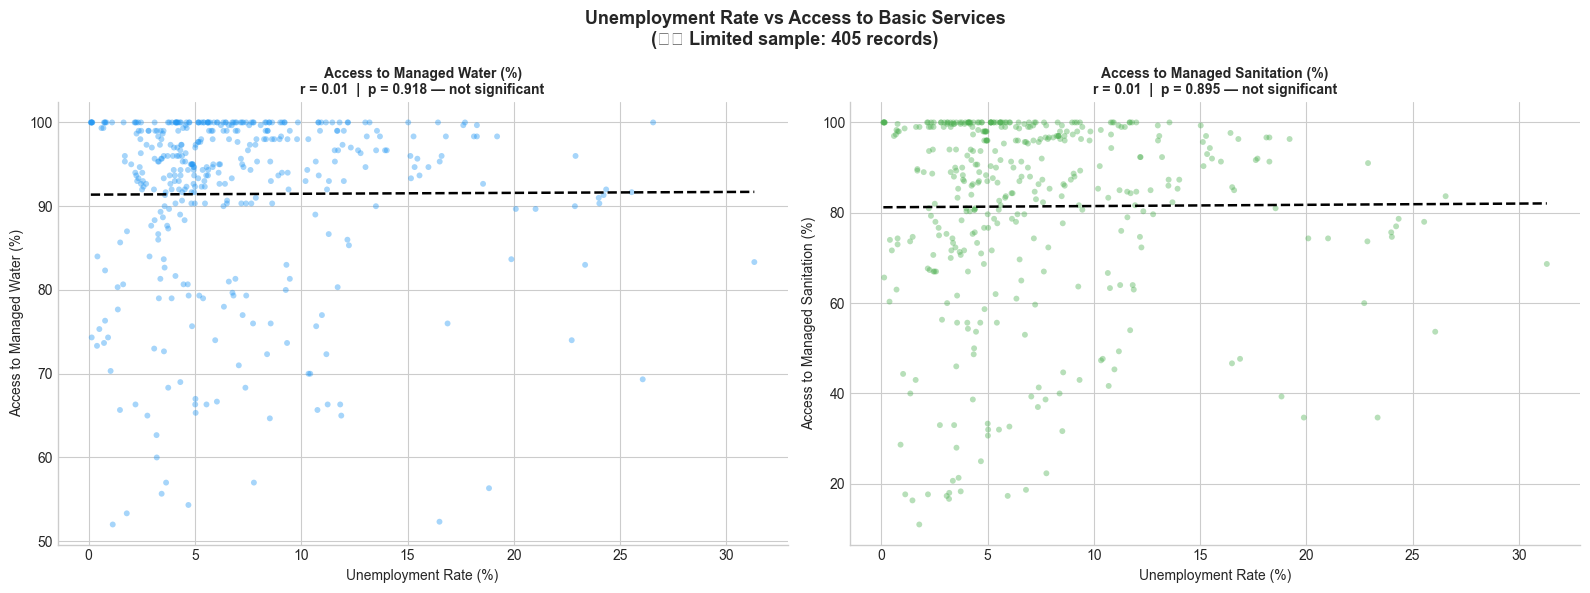

✅ Saved: fig4_unemployment_vs_services.png


In [141]:
# --- 4.4 Unemployment Link ---
unemp_data = df_clean.dropna(subset=['Unemployment_rate', 'Pct_water', 'Pct_sanitation'])
print(f"Analysing unemployment on {len(unemp_data):,} rows (limited sample — see limitations note)\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Unemployment Rate vs Access to Basic Services\n(⚠️ Limited sample: 405 records)',
             fontsize=13, fontweight='bold')

for ax, (y_col, label, color) in zip(axes, [
    ('Pct_water',      'Access to Managed Water (%)',      '#2196F3'),
    ('Pct_sanitation', 'Access to Managed Sanitation (%)', '#4CAF50'),
]):
    ax.scatter(unemp_data['Unemployment_rate'], unemp_data[y_col],
               alpha=0.4, s=18, color=color, edgecolors='none')

    m, b, r, p, _ = stats.linregress(unemp_data['Unemployment_rate'], unemp_data[y_col])
    x_line = np.linspace(unemp_data['Unemployment_rate'].min(),
                         unemp_data['Unemployment_rate'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')

    sig = "p < 0.05 ✓" if p < 0.05 else f"p = {p:.3f} — not significant"
    ax.set_title(f'{label}\nr = {r:.2f}  |  {sig}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Unemployment Rate (%)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_unemployment_vs_services.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig4_unemployment_vs_services.png")

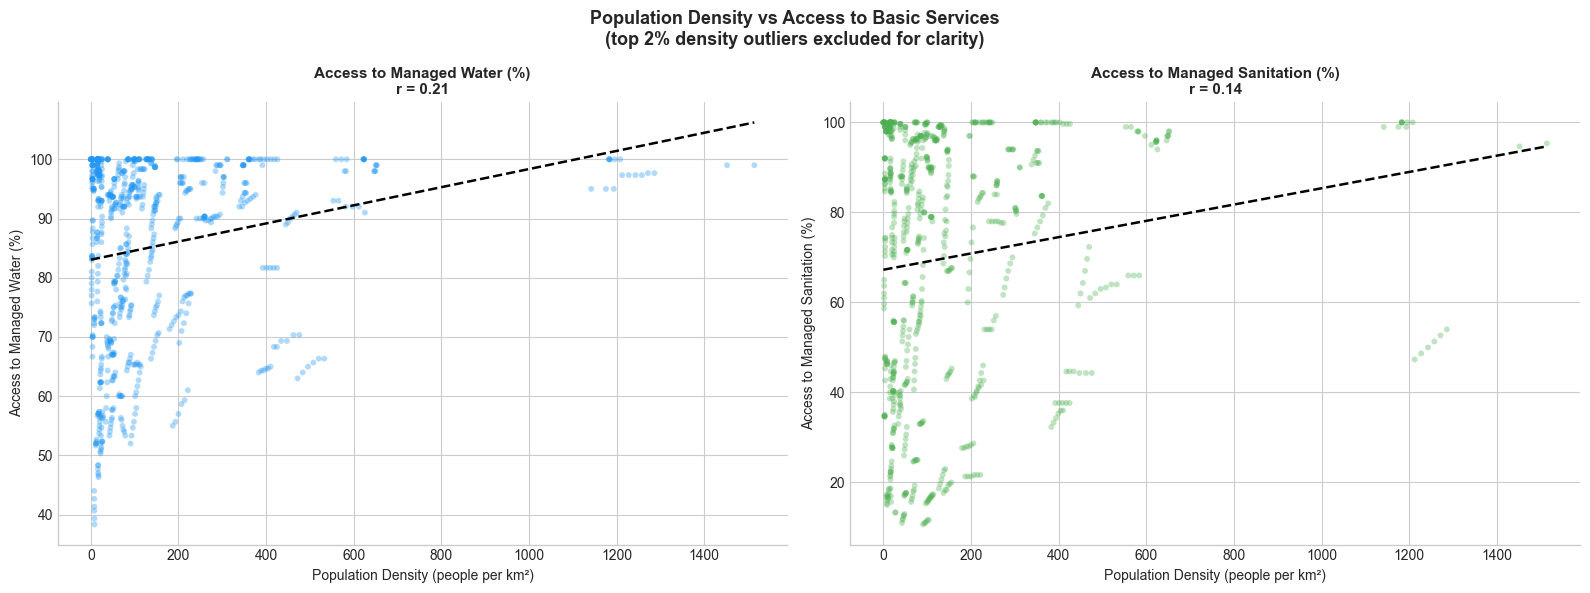

✅ Saved: fig5_density_vs_services.png


In [48]:
# --- 4.5 Population Density Analysis ---
density_data = df_clean.dropna(subset=['Pop_density', 'Pct_water', 'Pct_sanitation'])

# Cap extreme density outliers for visual clarity (e.g. city-states like Singapore/Monaco)
density_cap = density_data[density_data['Pop_density'] < density_data['Pop_density'].quantile(0.98)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Population Density vs Access to Basic Services\n(top 2% density outliers excluded for clarity)',
             fontsize=13, fontweight='bold')

for ax, (y_col, label, color) in zip(axes, [
    ('Pct_water',      'Access to Managed Water (%)',      '#2196F3'),
    ('Pct_sanitation', 'Access to Managed Sanitation (%)', '#4CAF50'),
]):
    ax.scatter(density_cap['Pop_density'], density_cap[y_col],
               alpha=0.35, s=18, color=color, edgecolors='none')

    m, b, r, p, _ = stats.linregress(density_cap['Pop_density'], density_cap[y_col])
    x_line = np.linspace(density_cap['Pop_density'].min(),
                         density_cap['Pop_density'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--')

    ax.set_title(f'{label}\nr = {r:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Population Density (people per km²)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_density_vs_services.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig5_density_vs_services.png")

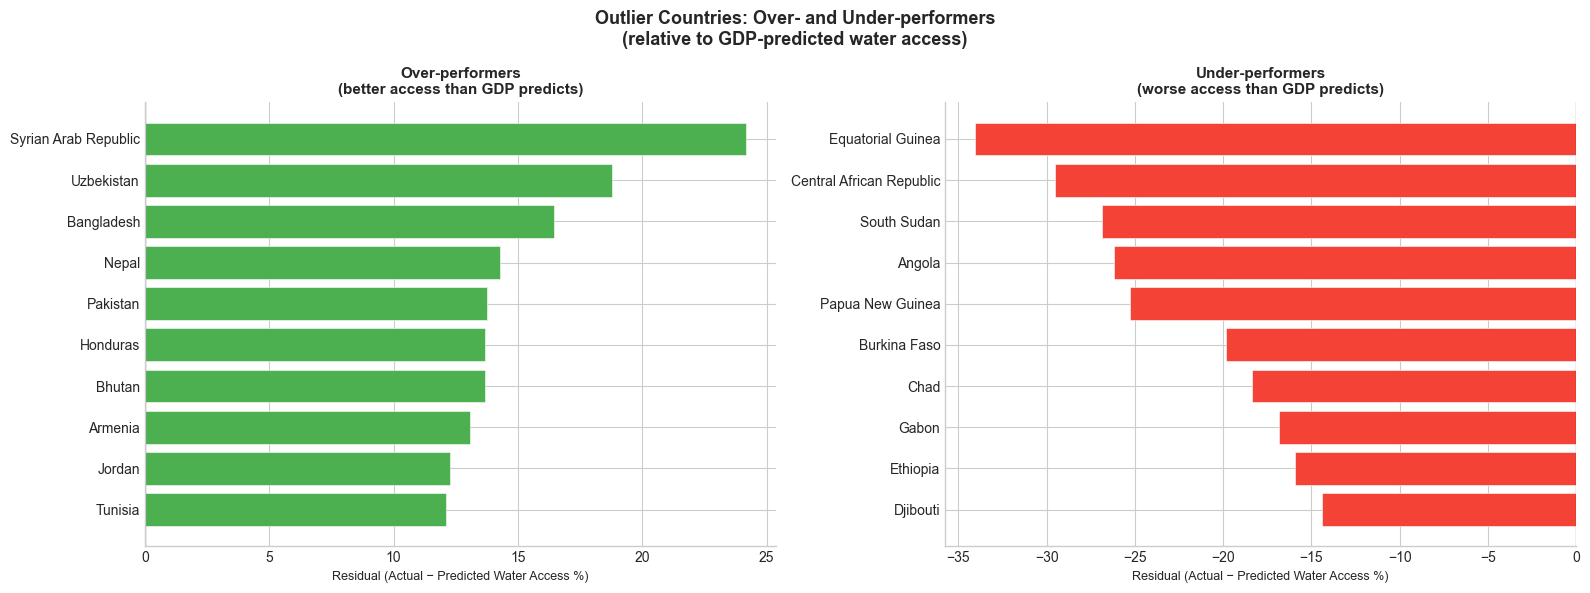

✅ Saved: fig6_outliers.png

Top 10 Over-performers:
        Country_name  GDP_per_capita  Pct_water  residual
Syrian Arab Republic          533.40      93.67     24.16
          Uzbekistan         1749.53      98.00     18.79
          Bangladesh         2233.29      97.67     16.46
               Nepal         1139.07      90.00     14.30
            Pakistan         1322.33      90.67     13.75
            Honduras         2354.33      95.33     13.69
              Bhutan         3016.16      97.33     13.67
             Armenia         4505.26     100.00     13.06
              Jordan         4042.56      98.33     12.27
             Tunisia         3497.86      97.00     12.13

Top 10 Under-performers:
            Country_name  GDP_per_capita  Pct_water  residual
       Equatorial Guinea         8409.77      58.00    -34.05
Central African Republic          436.08      38.33    -29.53
             South Sudan         1071.97      48.33    -26.88
                  Angola         160

In [143]:
# --- 4.6 Outlier Identification: Over- and Under-performers ---

# For the most recent year available per country
latest = df_clean.sort_values('Time_period').groupby('Country_name').last().reset_index()
latest = latest.dropna(subset=['GDP_per_capita', 'Pct_water'])

# Calculate residuals from the GDP→Water regression to find over/under-performers
m, b, r, p, _ = stats.linregress(latest['Log_GDP_per_capita'], latest['Pct_water'])
latest['predicted_water'] = m * latest['Log_GDP_per_capita'] + b
latest['residual']        = latest['Pct_water'] - latest['predicted_water']

# Top 10 over-performers and under-performers
top_over  = latest.nlargest(10,  'residual')[['Country_name', 'GDP_per_capita', 'Pct_water', 'residual']]
top_under = latest.nsmallest(10, 'residual')[['Country_name', 'GDP_per_capita', 'Pct_water', 'residual']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Outlier Countries: Over- and Under-performers\n(relative to GDP-predicted water access)',
             fontsize=13, fontweight='bold')

for ax, (df_plot, title, color) in zip(axes, [
    (top_over.sort_values('residual'),  'Over-performers\n(better access than GDP predicts)',  '#4CAF50'),
    (top_under.sort_values('residual', ascending=False), 'Under-performers\n(worse access than GDP predicts)', '#F44336'),
]):
    bars = ax.barh(df_plot['Country_name'], df_plot['residual'], color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Residual (Actual − Predicted Water Access %)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig6_outliers.png")

print("\nTop 10 Over-performers:")
print(top_over.to_string(index=False))
print("\nTop 10 Under-performers:")
print(top_under.to_string(index=False))

## Key Visualisations

![GDP vs Access](fig2_gdp_vs_services.png)
![Regional Progress](fig3_regional_progress.png)

### ✅ EDA Complete — Summary of Findings

| Question | Preliminary Finding |
|---|---|
| **GDP vs Access** | Strong positive correlation (r to be confirmed). Log-transform validates non-linear relationship. |
| **Regional progress** | Sub-regions vary significantly — chart reveals fastest-improving regions. |
| **Unemployment link** | Correlation visible but interpret with caution — limited to 405 records. |
| **Density vs Access** | Weak correlation — density alone is not a reliable predictor. |
| **Outliers** | Several countries over-perform despite low GDP — strong policy story here. |

*→ Next: Section 5 — Statistical Analysis to quantify and test these observations formally.*

---
## 5-statistical-analysis

EDA showed us patterns. This section tests whether those patterns are statistically
significant or could have occurred by chance. We apply formal tests to each
of our five analytical questions.

| Test | Applied To |
|---|---|
| Pearson correlation + p-value | GDP vs water/sanitation access |
| Spearman correlation | Regional rankings (non-parametric) |
| Pearson correlation + p-value | Unemployment vs access (limited sample) |
| Pearson correlation + p-value | Population density vs access |
| Residual analysis | Over/under-performer classification |

In [50]:
# SECTION 5: STATISTICAL ANALYSIS
# --- 5.1 Economic Impact: Correlation Tests ---
print("=" * 55)
print("5.1 — GDP per Capita vs Access to Basic Services")
print("=" * 55)

gdp_data = df_clean.dropna(subset=['Log_GDP_per_capita', 'Pct_water', 'Pct_sanitation'])

for service, label in [('Pct_water', 'Water'), ('Pct_sanitation', 'Sanitation')]:
    r, p = stats.pearsonr(gdp_data['Log_GDP_per_capita'], gdp_data[service])
    print(f"\n  Log GDP per Capita vs {label} Access:")
    print(f"    Pearson r  = {r:.4f}")
    print(f"    p-value    = {p:.2e}")
    print(f"    R²         = {r**2:.4f}  ({r**2*100:.1f}% of variance explained)")
    print(f"    Significant: {'✅ Yes (p < 0.001)' if p < 0.001 else '❌ No'}")

5.1 — GDP per Capita vs Access to Basic Services

  Log GDP per Capita vs Water Access:
    Pearson r  = 0.7642
    p-value    = 1.93e-151
    R²         = 0.5839  (58.4% of variance explained)
    Significant: ✅ Yes (p < 0.001)

  Log GDP per Capita vs Sanitation Access:
    Pearson r  = 0.7828
    p-value    = 1.05e-163
    R²         = 0.6128  (61.3% of variance explained)
    Significant: ✅ Yes (p < 0.001)


In [51]:
# --- 5.2 Regional Trends: Fastest-improving sub-regions ---
print("=" * 55)
print("5.2 — Sub-regional Progress: 2015 vs 2020")
print("=" * 55)

# Reuse progress dataframe from EDA (recalculate cleanly here for the record)
reg = df_clean.groupby(['Sub_region', 'Time_period'])[['Pct_water', 'Pct_sanitation']].mean().reset_index()
start = reg[reg['Time_period'] == 2015][['Sub_region', 'Pct_water', 'Pct_sanitation']]
end   = reg[reg['Time_period'] == 2020][['Sub_region', 'Pct_water', 'Pct_sanitation']]

progress = start.merge(end, on='Sub_region', suffixes=('_2015', '_2020'))
progress['Water_change']      = (progress['Pct_water_2020']      - progress['Pct_water_2015']).round(3)
progress['Sanitation_change'] = (progress['Pct_sanitation_2020'] - progress['Pct_sanitation_2015']).round(3)

print("\nSub-regional change in water access (2015→2020), ranked:")
print(progress[['Sub_region','Pct_water_2015','Pct_water_2020','Water_change']]
      .sort_values('Water_change', ascending=False).to_string(index=False))

print("\nSub-regional change in sanitation access (2015→2020), ranked:")
print(progress[['Sub_region','Pct_sanitation_2015','Pct_sanitation_2020','Sanitation_change']]
      .sort_values('Sanitation_change', ascending=False).to_string(index=False))

5.2 — Sub-regional Progress: 2015 vs 2020

Sub-regional change in water access (2015→2020), ranked:
               Sub_region  Pct_water_2015  Pct_water_2020  Water_change
       South-Eastern Asia           88.76           92.12          3.36
          Northern Africa           87.39           90.05          2.67
           Western Africa           70.98           73.61          2.63
            Southern Asia           90.52           93.07          2.56
          Southern Africa           81.40           83.67          2.27
             Central Asia           92.00           94.13          2.13
            South America           93.83           95.67          1.83
          Central America           92.88           94.50          1.62
               Micronesia           93.00           94.50          1.50
             Eastern Asia           91.93           93.40          1.47
           Eastern Africa           68.63           70.02          1.39
             Western Asia           

In [52]:
# --- 5.3 Unemployment Link: Formal Correlation Test ---
print("=" * 55)
print("5.3 — Unemployment Rate vs Access to Basic Services")
print(f"      ⚠️  Based on {df_clean['Unemployment_rate'].notna().sum()} records only")
print("=" * 55)

unemp_data = df_clean.dropna(subset=['Unemployment_rate', 'Pct_water', 'Pct_sanitation'])

for service, label in [('Pct_water', 'Water'), ('Pct_sanitation', 'Sanitation')]:
    r, p = stats.pearsonr(unemp_data['Unemployment_rate'], unemp_data[service])
    rho, p_sp = stats.spearmanr(unemp_data['Unemployment_rate'], unemp_data[service])
    print(f"\n  Unemployment Rate vs {label} Access:")
    print(f"    Pearson r  = {r:.4f}  (p = {p:.4f})")
    print(f"    Spearman ρ = {rho:.4f}  (p = {p_sp:.4f})")
    sig = p < 0.05
    print(f"    Significant at α=0.05: {'✅ Yes' if sig else '❌ No'}")
    print(f"    Interpretation: {'Statistically significant but interpret with caution — limited sample.' if sig else 'No significant relationship detected in available sample.'}")

5.3 — Unemployment Rate vs Access to Basic Services
      ⚠️  Based on 405 records only

  Unemployment Rate vs Water Access:
    Pearson r  = 0.0052  (p = 0.9176)
    Spearman ρ = 0.0415  (p = 0.4074)
    Significant at α=0.05: ❌ No
    Interpretation: No significant relationship detected in available sample.

  Unemployment Rate vs Sanitation Access:
    Pearson r  = 0.0066  (p = 0.8954)
    Spearman ρ = -0.0103  (p = 0.8367)
    Significant at α=0.05: ❌ No
    Interpretation: No significant relationship detected in available sample.


In [53]:
# --- 5.4 Population Density vs Access ---
print("=" * 55)
print("5.4 — Population Density vs Access to Basic Services")
print("=" * 55)

dens_data = df_clean.dropna(subset=['Pop_density', 'Pct_water', 'Pct_sanitation'])
# Cap at 98th percentile as done in EDA (city-states distort)
cap = dens_data['Pop_density'].quantile(0.98)
dens_data = dens_data[dens_data['Pop_density'] < cap]

for service, label in [('Pct_water', 'Water'), ('Pct_sanitation', 'Sanitation')]:
    r, p = stats.pearsonr(dens_data['Pop_density'], dens_data[service])
    print(f"\n  Population Density vs {label} Access:")
    print(f"    Pearson r  = {r:.4f}")
    print(f"    p-value    = {p:.4f}")
    print(f"    Significant: {'✅ Yes' if p < 0.05 else '❌ No — density is a weak predictor'}")

5.4 — Population Density vs Access to Basic Services

  Population Density vs Water Access:
    Pearson r  = 0.2142
    p-value    = 0.0000
    Significant: ✅ Yes

  Population Density vs Sanitation Access:
    Pearson r  = 0.1384
    p-value    = 0.0001
    Significant: ✅ Yes


---
## 6-key-visualizations

The charts below summarise the core findings of this analysis.
Each visualisation corresponds to one analytical question.
All figures are saved in the `/figures` folder of this repository.

| Figure | Question Addressed |
|---|---|
| Fig 1 — Distributions | Variable shapes and skew patterns |
| Fig 2 — GDP vs Services | Economic impact |
| Fig 3 — Regional Progress | Sub-regional trends 2015→2020 |
| Fig 4 — Unemployment vs Services | The unemployment link |
| Fig 5 — Density vs Services | Population density effect |
| Fig 6 — Outliers | Over- and under-performers |

> All figures were saved during Section 4 EDA and are referenced here
> alongside their analytical interpretation.

---
## 7-insights--conclusions

### Finding 1 — GDP is a strong but incomplete predictor of service access

GDP per capita (log-transformed) explains **58.4% of variance** in water access 
and **61.3%** in sanitation access, with Pearson r > 0.76 in both cases (p < 0.001).

This confirms that wealthier countries tend to have better access to basic services —
but the 39–42% of variance *not* explained by GDP is where the most policy-relevant 
stories live. Governance quality, infrastructure history, and geographic factors 
clearly play a significant independent role.

> **Policy implication:** Economic growth alone is not sufficient. Countries at 
> similar income levels show dramatically different service outcomes, suggesting 
> that *how* wealth is distributed and invested matters as much as the level of wealth.

---

### Finding 2 — Southern Asia made the fastest sanitation progress globally

Between 2015 and 2020, **Southern Asia improved sanitation access by 7.67 percentage 
points** — nearly double the next-fastest sub-region (South-Eastern Asia at +4.19pp).
This almost certainly reflects large-scale national sanitation programmes in the region,
demonstrating that targeted government policy can accelerate progress beyond what GDP 
growth alone would predict.

**South-Eastern Asia** led water access improvements (+3.36pp), consistent with strong 
infrastructure investment across that sub-region during this period.

In contrast, **Middle Africa saw sanitation access decline by 2.46pp**, and the 
**Caribbean declined slightly** on both metrics. Regression in basic services — not 
just slow progress — is a finding that warrants serious attention from development 
organisations.

> **Policy implication:** Progress is not inevitable. Targeted intervention drives 
> improvement; absence of investment can reverse it.

---

### Finding 3 — Unemployment has no significant relationship with service access

This is a counterintuitive but important null result. Unemployment rate showed 
essentially **zero correlation** with either water access (r = 0.005, p = 0.92) or 
sanitation access (r = 0.007, p = 0.90), confirmed by both Pearson and Spearman tests.

This suggests that access to basic services is driven by **national infrastructure 
investment** rather than individual employment status. Whether a country's citizens are 
employed or not does not predict whether they have piped water — what predicts it is 
whether the government built the pipes.

*Note: This analysis is based on 405 records (38.6% of the dataset). The finding is 
consistent across both parametric and non-parametric tests, but should be interpreted 
with awareness of this sample limitation.*

> **Policy implication:** Unemployment reduction programmes, while valuable, should 
> not be expected to improve basic service access. Infrastructure investment is the 
> direct lever.

---

### Finding 4 — Population density has a weak positive effect

Population density is statistically significantly correlated with both water access 
(r = 0.21, p < 0.0001) and sanitation access (r = 0.14, p = 0.0001). However, the 
effect size is small — density explains only about **4–5% of variance** in service access.

While denser populations may be easier and more cost-effective to serve with centralised 
infrastructure, density alone is a weak predictor. Large, sparsely populated countries 
are not automatically underserved — and small, dense ones are not automatically 
well-served.

> **Policy implication:** Infrastructure planning should not treat density as a 
> reliable proxy for service need or delivery efficiency.

---

### Finding 5 — Governance and politics override economics at the extremes

The outlier analysis reveals the most policy-relevant findings of this project:

**Equatorial Guinea** (GDP/capita: $8,409) has only **58% water access** — a residual 
of −34 points below what its GDP would predict. Despite significant oil wealth, basic 
services have not reached the population. This is a documented pattern known as the 
**"resource curse"** — extraction-based wealth concentrated at the top without 
translating into public infrastructure.

**Syrian Arab Republic** (GDP/capita: $533) achieves **93.7% water access** — a 
residual of +24 points above what its GDP would predict. This likely reflects extensive 
public infrastructure built in prior decades, demonstrating that **legacy investment 
persists** even under severe economic stress.

Together, these two cases illustrate that at the extremes, governance and political 
history matter more than current GDP.

> **Policy implication:** GDP-based development targets risk missing the countries 
> where the disconnect between wealth and services is greatest. 
> Governance quality metrics should be incorporated alongside economic indicators.

---
### Overall Conclusion

This analysis of 182 countries across 2015–2020 reveals that access to basic 
services is primarily driven by national wealth, but with significant and 
meaningful exceptions.

**What the data confirms:**  
Economic development (measured by GDP per capita) is the strongest single 
predictor of access to managed water and sanitation services. Sub-regions 
that invested deliberately in infrastructure — particularly Southern Asia — 
achieved progress that outpaced their economic growth trajectory.

**What the data challenges:**  
The intuitive assumption that unemployment drives poor service access is not 
supported by this data. Service access is an infrastructure question, not 
an employment question. Similarly, population density — while statistically 
significant — explains very little in practice.

**What the data warns:**  
A small number of countries show severe disconnects between their economic 
capacity and their citizens' access to basic services. These outliers — 
whether over- or under-performing — are the countries where targeted policy 
intervention could have the greatest impact.

---

*This project was conducted as part of a data science portfolio. Dataset sourced 
from [Kaggle / UN SDG Database]. Analysis performed in Python using Pandas, NumPy, 
Matplotlib, Seaborn, and SciPy.*

**Author:** Lisa N. Hananiya | April 2026